<a href="https://colab.research.google.com/github/AngellyC07/Ciencia_de_datos/blob/main/Pima_Indians.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# BLOQUE 1. IMPORTAR LIBRERÍAS Y CARGAR DATOS
# ==========================================

# pandas se usa para manejar tablas de datos
import pandas as pd

# numpy se usa para operaciones numéricas
import numpy as np

# matplotlib se usa para gráficas básicas
import matplotlib.pyplot as plt

# seaborn se usa para gráficas estadísticas más claras
import seaborn as sns

# scipy.stats permite hacer pruebas estadísticas
from scipy import stats

In [ ]:
# configuración visual general de las gráficas
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# cargar el dataset
df = pd.read_csv("diabetes.csv")

In [ ]:
# mostrar primeras filas
print("Primeras 5 filas del dataset:")
print(df.head())

Primeras 5 filas del dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
# mostrar nombres de columnas
print("\nColumnas del dataset:")
print(df.columns.tolist())


Columnas del dataset:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
# ==========================================
# BLOQUE 2. REVISIÓN GENERAL DEL DATASET
# ==========================================

# información general: tipos de datos y cantidad de registros no nulos
print("Información general:")
print(df.info())

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [ ]:
# contar nulos reales
print("\nValores nulos reales por columna:")
print(df.isnull().sum())


Valores nulos reales por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# estadísticas descriptivas básicas
print("\nResumen estadístico general:")
print(df.describe().T)


Resumen estadístico general:
                          count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
BloodPressure             768.0   69.105469   19.355807   0.000  62.00000   
SkinThickness             768.0   20.536458   15.952218   0.000   0.00000   
Insulin                   768.0   79.799479  115.244002   0.000   0.00000   
BMI                       768.0   31.992578    7.884160   0.000  27.30000   
DiabetesPedigreeFunction  768.0    0.471876    0.331329   0.078   0.24375   
Age                       768.0   33.240885   11.760232  21.000  24.00000   
Outcome                   768.0    0.348958    0.476951   0.000   0.00000   

                               50%        75%     max  
Pregnancies                 3.0000    6.00000   17.00  
Glucose                   117.0000  140.25000  199.00  
BloodPressure              72.0

In [ ]:
# revisar duplicados
print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())


Cantidad de filas duplicadas:
0


In [ ]:
# distribución de la variable objetivo
print("\nConteo de Outcome:")
print(df["Outcome"].value_counts())


Conteo de Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
# distribución porcentual de la variable objetivo
print("\nPorcentaje de Outcome:")
print(df["Outcome"].value_counts(normalize=True) * 100)


Porcentaje de Outcome:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [ ]:
# ==========================================
# BLOQUE 3. DETECTAR CEROS IMPOSIBLES
# ==========================================

# estas variables no deberían tomar cero desde un punto de vista clínico
# o un cero suele ser un valor faltante disfrazado
columnas_cero_invalido = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Cantidad de ceros por variable sospechosa:")
for col in columnas_cero_invalido:
    cantidad = (df[col] == 0).sum()
    porcentaje = (df[col] == 0).mean() * 100
    print(f"{col}: {cantidad} ceros ({porcentaje:.2f}%)")

Cantidad de ceros por variable sospechosa:
Glucose: 5 ceros (0.65%)
BloodPressure: 35 ceros (4.56%)
SkinThickness: 227 ceros (29.56%)
Insulin: 374 ceros (48.70%)
BMI: 11 ceros (1.43%)


In [ ]:
# ==========================================
# BLOQUE 4. CONVERTIR CEROS INVÁLIDOS A NaN
# ==========================================

# hacer una copia del dataset original para no modificarlo directamente
df_clean = df.copy()

# reemplazar ceros inválidos por NaN
for col in columnas_cero_invalido:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# verificar cuántos faltantes quedaron
print("Valores faltantes después de convertir ceros inválidos en NaN:")
print(df_clean.isnull().sum())

Valores faltantes después de convertir ceros inválidos en NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
# ==========================================
# BLOQUE 5. MEDIDAS DESCRIPTIVAS DETALLADAS
# ==========================================

# lista de variables predictoras
variables = [col for col in df_clean.columns if col != "Outcome"]

# crear resumen estadístico enriquecido
resumen = pd.DataFrame({
    "count_validos": df_clean[variables].count(),
    "missing": df_clean[variables].isnull().sum(),
    "missing_%": df_clean[variables].isnull().mean() * 100,
    "mean": df_clean[variables].mean(),
    "median": df_clean[variables].median(),
    "std": df_clean[variables].std(),
    "var": df_clean[variables].var(),
    "min": df_clean[variables].min(),
    "q1": df_clean[variables].quantile(0.25),
    "q3": df_clean[variables].quantile(0.75),
    "max": df_clean[variables].max(),
    "skew": df_clean[variables].skew(),
    "kurtosis": df_clean[variables].kurtosis()
})

print("Resumen estadístico detallado:")
print(resumen.sort_index())

Resumen estadístico detallado:
                          count_validos  missing  missing_%        mean  \
Age                                 768        0   0.000000   33.240885   
BMI                                 757       11   1.432292   32.457464   
BloodPressure                       733       35   4.557292   72.405184   
DiabetesPedigreeFunction            768        0   0.000000    0.471876   
Glucose                             763        5   0.651042  121.686763   
Insulin                             394      374  48.697917  155.548223   
Pregnancies                         768        0   0.000000    3.845052   
SkinThickness                       541      227  29.557292   29.153420   

                            median         std           var     min  \
Age                        29.0000   11.760232    138.303046  21.000   
BMI                        32.3000    6.924988     47.955463  18.200   
BloodPressure              72.0000   12.382158    153.317842  24.000   
Diabe

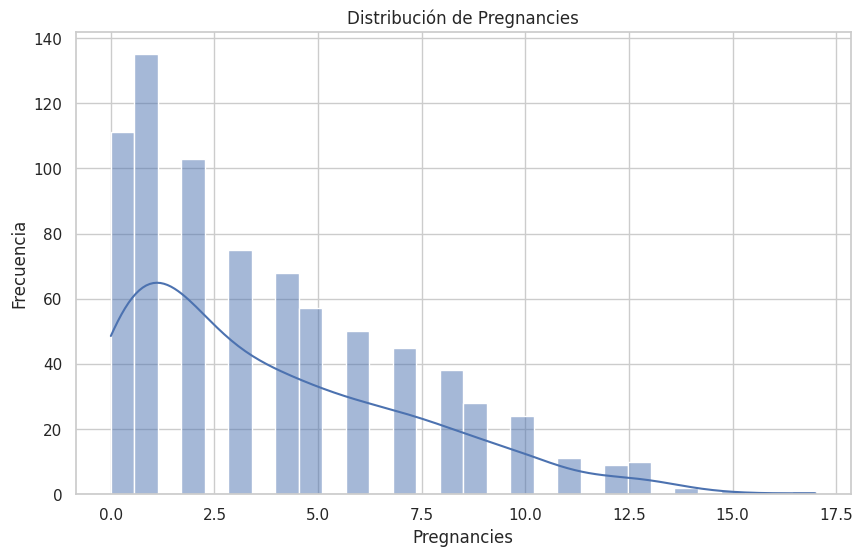

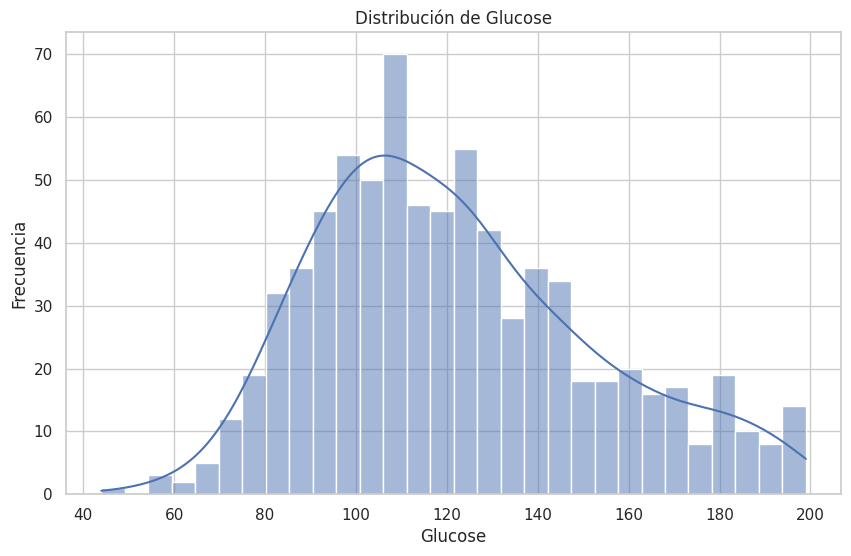

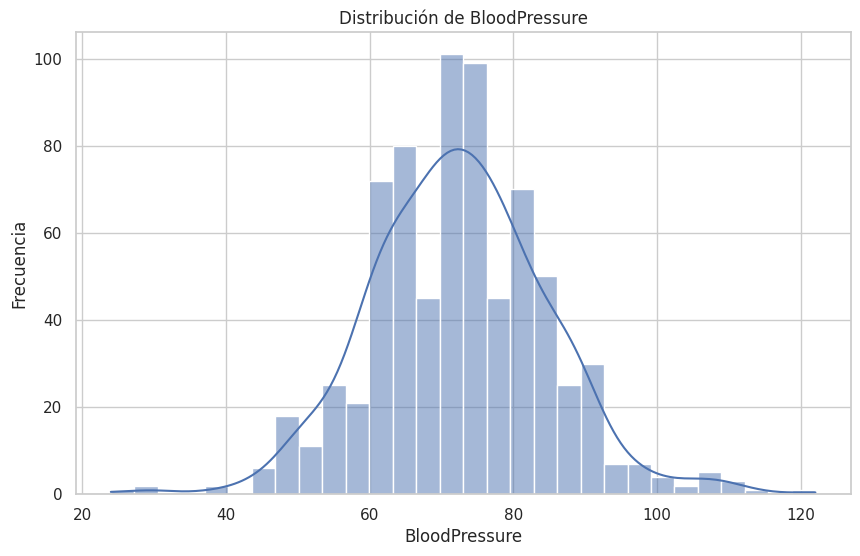

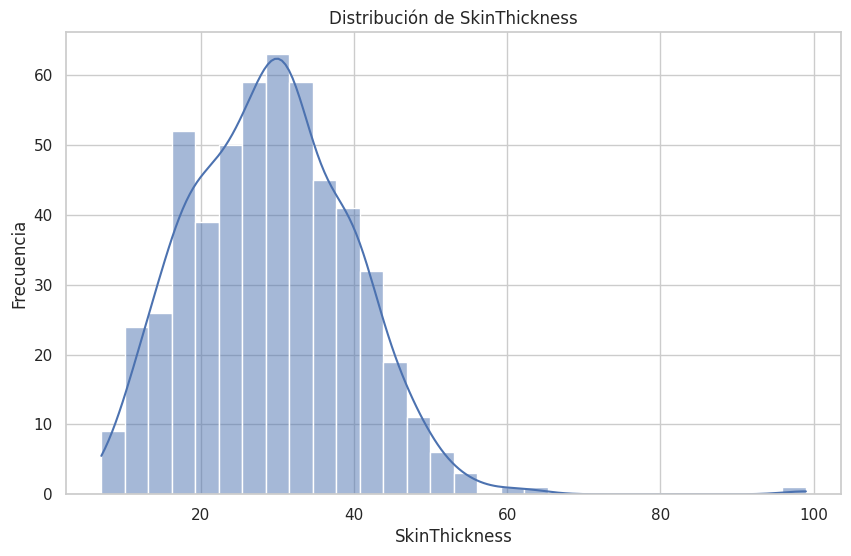

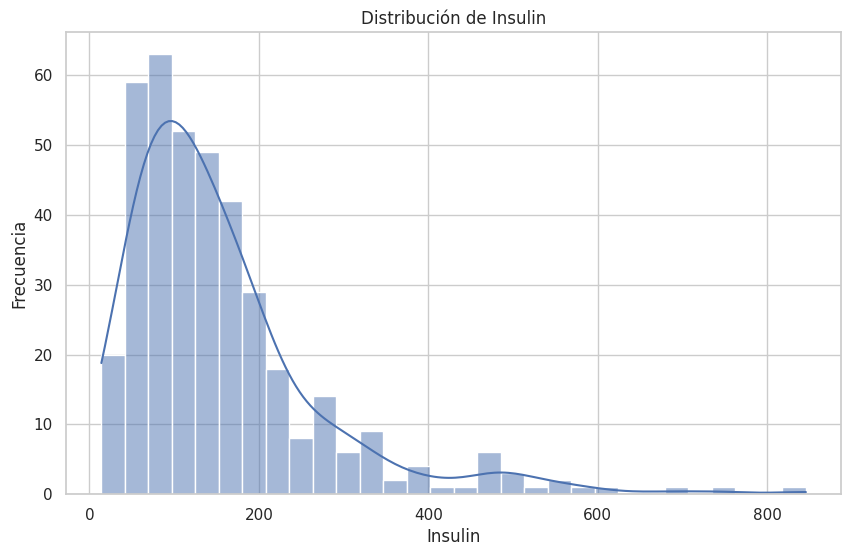

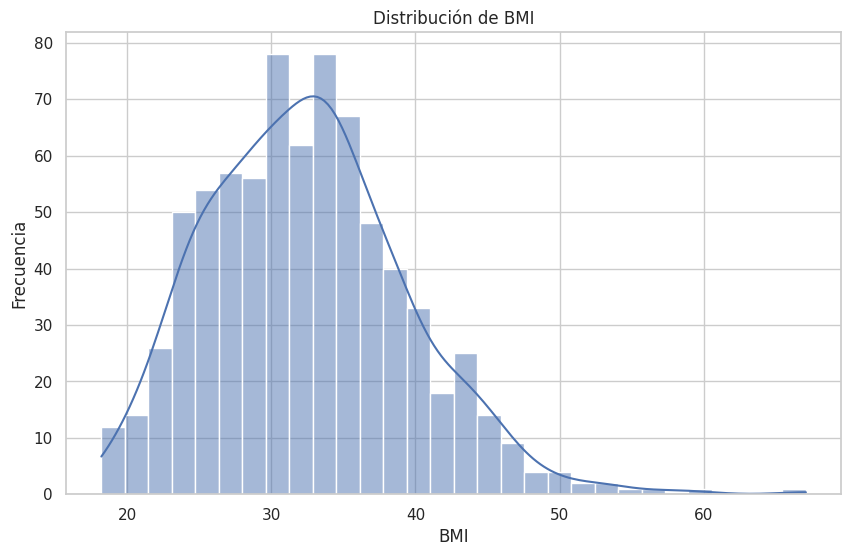

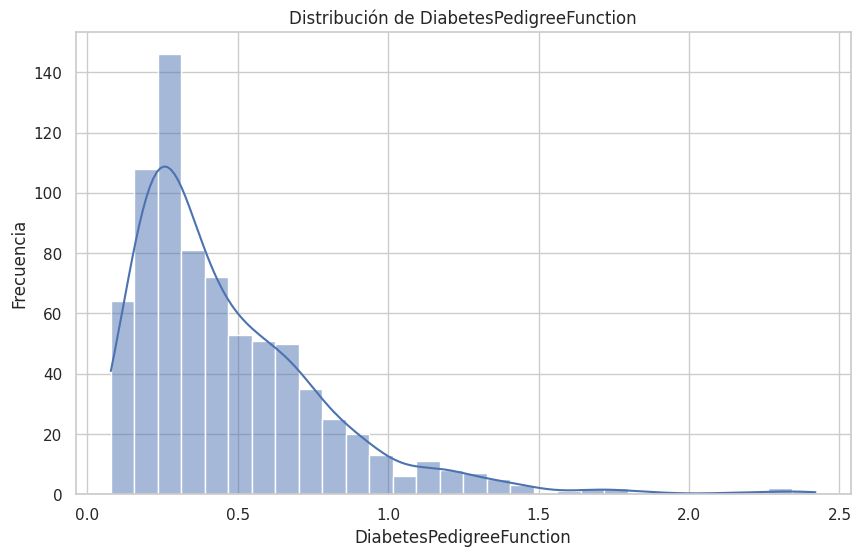

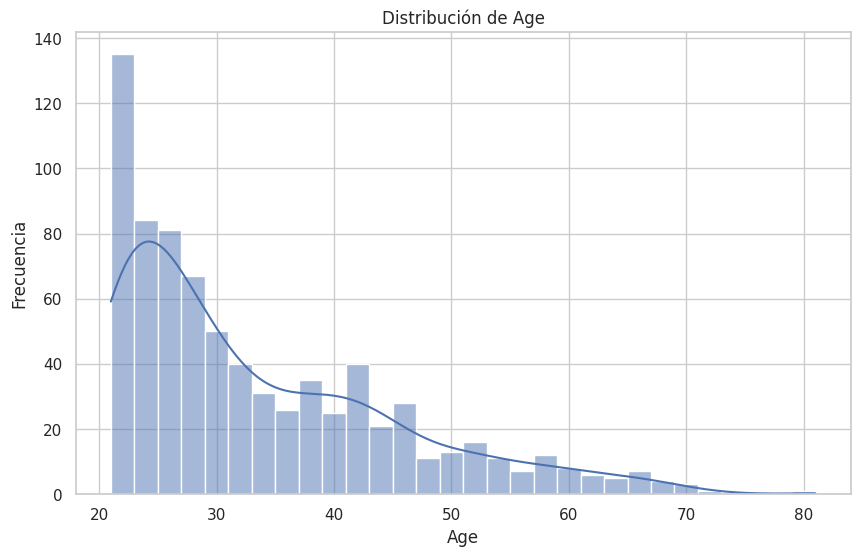

In [ ]:
# ==========================================
# BLOQUE 6. HISTOGRAMAS Y DENSIDADES
# ==========================================

for col in variables:
    plt.figure()

    # histograma con curva de densidad
    sns.histplot(df_clean[col].dropna(), bins=30, kde=True)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

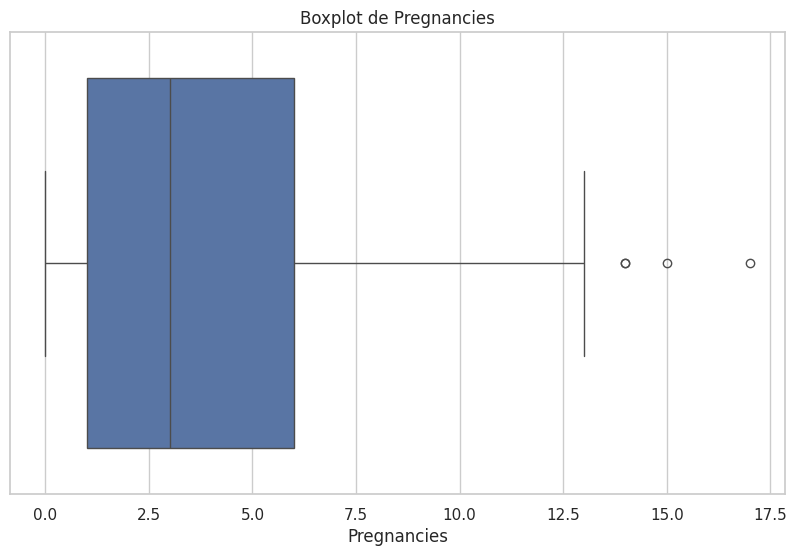

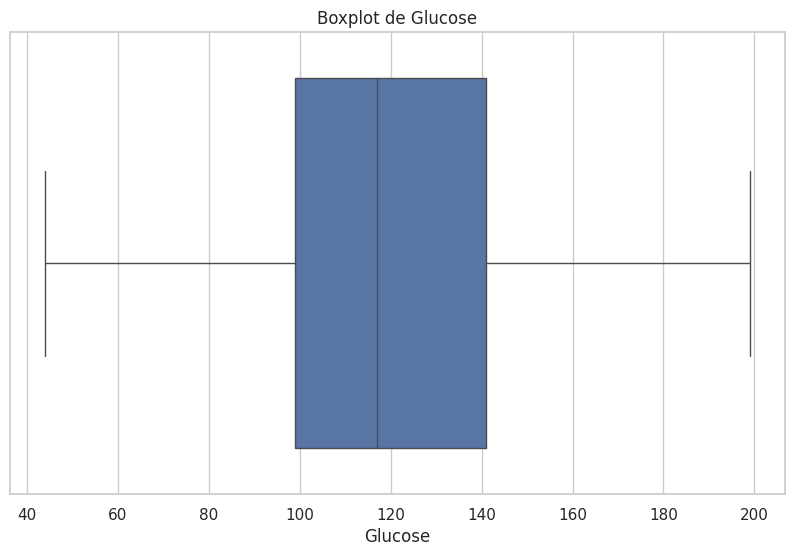

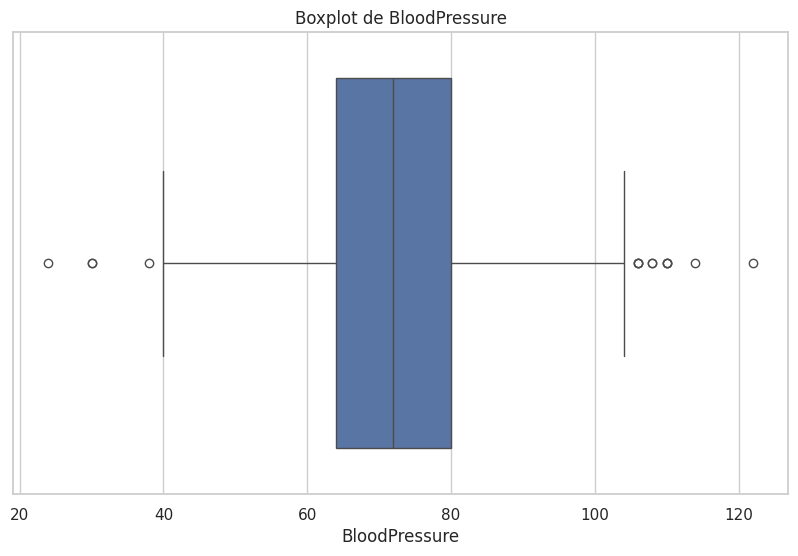

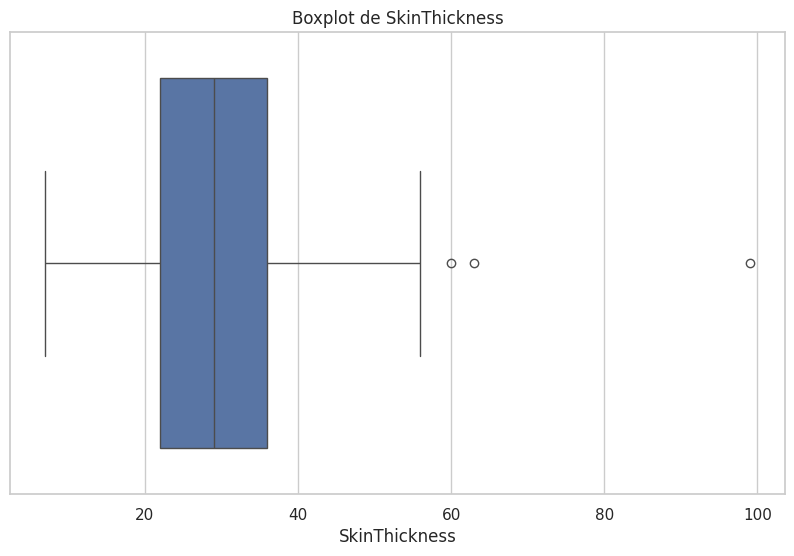

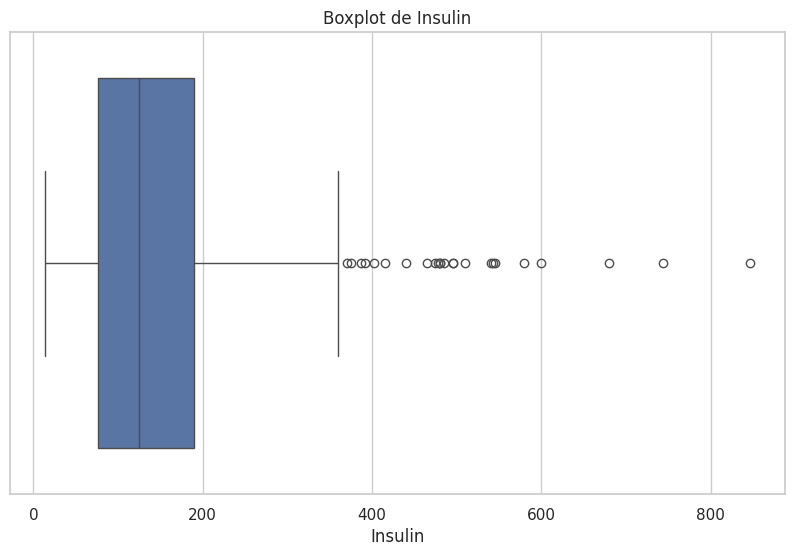

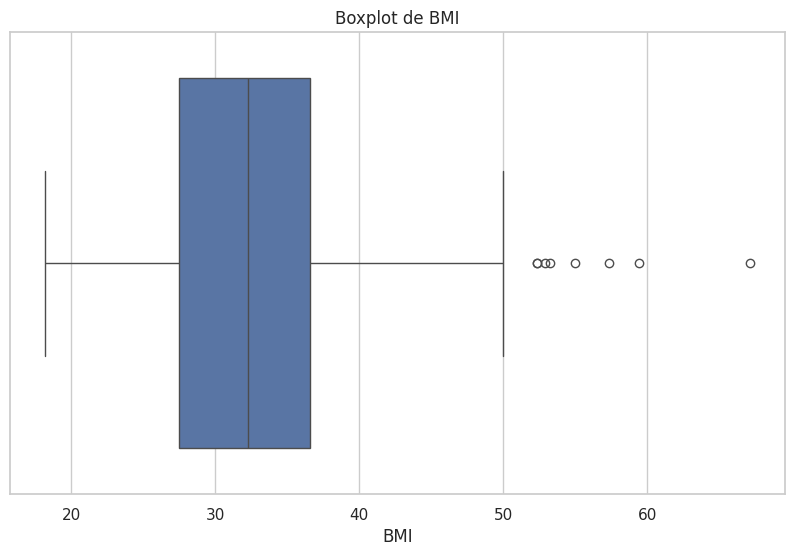

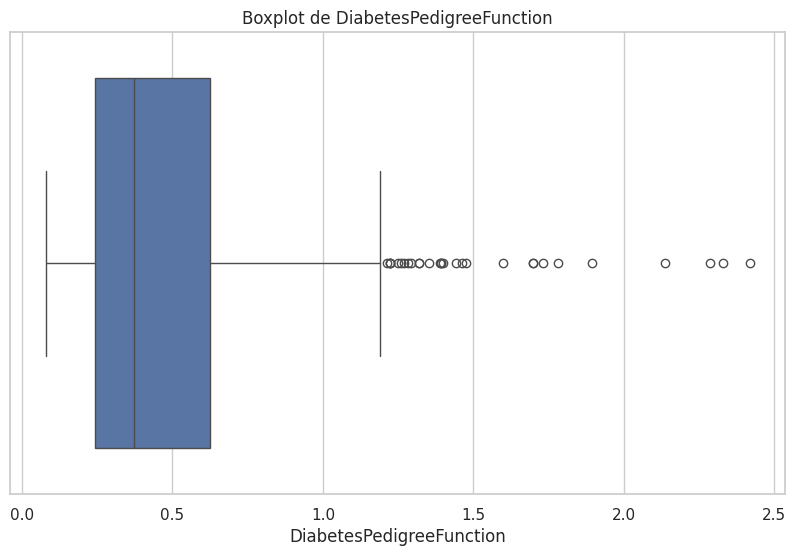

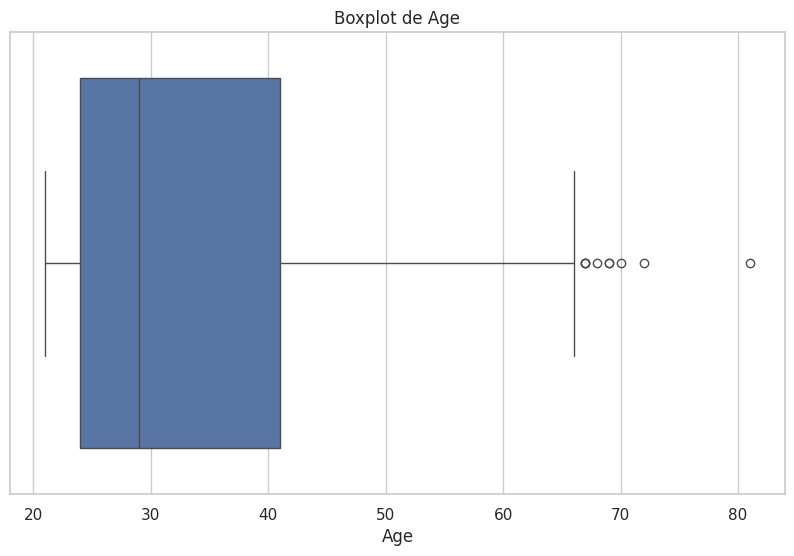

In [ ]:
# ==========================================
# BLOQUE 7. BOXPLOTS Y OUTLIERS
# ==========================================

for col in variables:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

In [ ]:
# ==========================================
# BLOQUE 8. DETECCIÓN FORMAL DE OUTLIERS (IQR)
# ==========================================

# crear lista para guardar resultados
tabla_outliers = []

for col in variables:
    # eliminar NaN para calcular percentiles bien
    serie = df_clean[col].dropna()

    # calcular cuartiles
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    # calcular rango intercuartílico
    iqr = q3 - q1

    # definir límites de outliers
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    # contar outliers
    n_outliers = ((serie < lim_inf) | (serie > lim_sup)).sum()
    pct_outliers = n_outliers / len(serie) * 100

    tabla_outliers.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Limite_inferior": lim_inf,
        "Limite_superior": lim_sup,
        "Cantidad_outliers": n_outliers,
        "Porcentaje_outliers": pct_outliers
    })

tabla_outliers = pd.DataFrame(tabla_outliers).sort_values("Porcentaje_outliers", ascending=False)

print("Tabla de outliers por criterio IQR:")
print(tabla_outliers)

Tabla de outliers por criterio IQR:
                   Variable        Q1         Q3       IQR  Limite_inferior  \
4                   Insulin  76.25000  190.00000  113.7500          -94.375   
6  DiabetesPedigreeFunction   0.24375    0.62625    0.3825           -0.330   
2             BloodPressure  64.00000   80.00000   16.0000           40.000   
7                       Age  24.00000   41.00000   17.0000           -1.500   
5                       BMI  27.50000   36.60000    9.1000           13.850   
3             SkinThickness  22.00000   36.00000   14.0000            1.000   
0               Pregnancies   1.00000    6.00000    5.0000           -6.500   
1                   Glucose  99.00000  141.00000   42.0000           36.000   

   Limite_superior  Cantidad_outliers  Porcentaje_outliers  
4          360.625                 24             6.091371  
6            1.200                 29             3.776042  
2          104.000                 14             1.909959  
7       

In [ ]:
# ==========================================
# BLOQUE 9. PROBABILIDAD EMPÍRICA GLOBAL
# ==========================================

# calcular frecuencia absoluta
conteo_outcome = df_clean["Outcome"].value_counts().sort_index()

# calcular probabilidad empírica
prob_outcome = df_clean["Outcome"].value_counts(normalize=True).sort_index()

print("Conteos de Outcome:")
print(conteo_outcome)

Conteos de Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
# calcular probabilidad empírica
prob_outcome = df_clean["Outcome"].value_counts(normalize=True).sort_index()

print("\nProbabilidades empíricas de Outcome:")
print(prob_outcome)


Probabilidades empíricas de Outcome:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


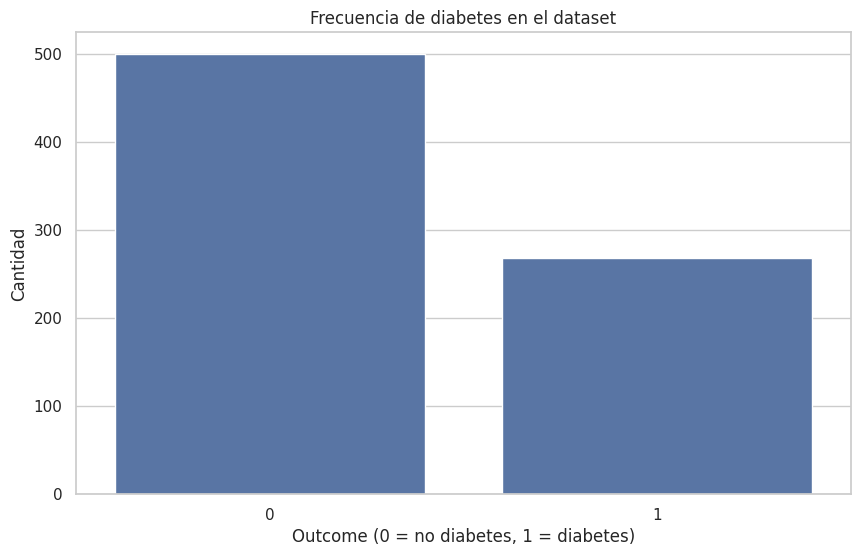

In [ ]:
# gráfico de barras
plt.figure()
sns.countplot(data=df_clean, x="Outcome")
plt.title("Frecuencia de diabetes en el dataset")
plt.xlabel("Outcome (0 = no diabetes, 1 = diabetes)")
plt.ylabel("Cantidad")
plt.show()

In [ ]:
# ==========================================
# BLOQUE 10. COMPARACIÓN POR GRUPOS
# ==========================================

# agrupar por Outcome y calcular estadísticas clave
comparacion = df_clean.groupby("Outcome")[variables].agg(["count", "mean", "median", "std"])

print("Comparación descriptiva entre personas con y sin diabetes:")
print(comparacion)

Comparación descriptiva entre personas con y sin diabetes:
        Pregnancies                            Glucose                     \
              count      mean median       std   count        mean median   
Outcome                                                                     
0               500  3.298000    2.0  3.017185     497  110.643863  107.0   
1               268  4.865672    4.0  3.741239     266  142.319549  140.0   

                   BloodPressure             ...    BMI            \
               std         count       mean  ... median       std   
Outcome                                      ...                    
0        24.776906           481  70.877339  ...   30.1  6.560737   
1        29.599199           252  75.321429  ...   34.3  6.614982   

        DiabetesPedigreeFunction                              Age             \
                           count      mean median       std count       mean   
Outcome                                          

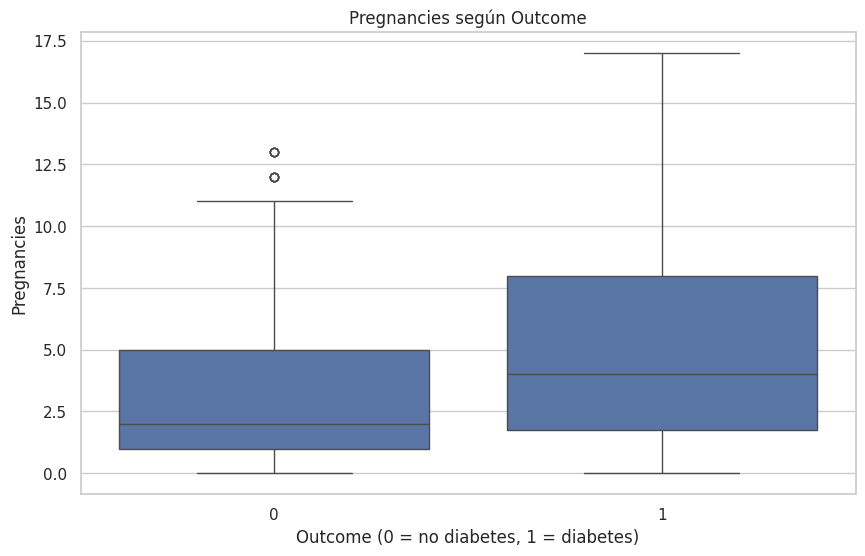

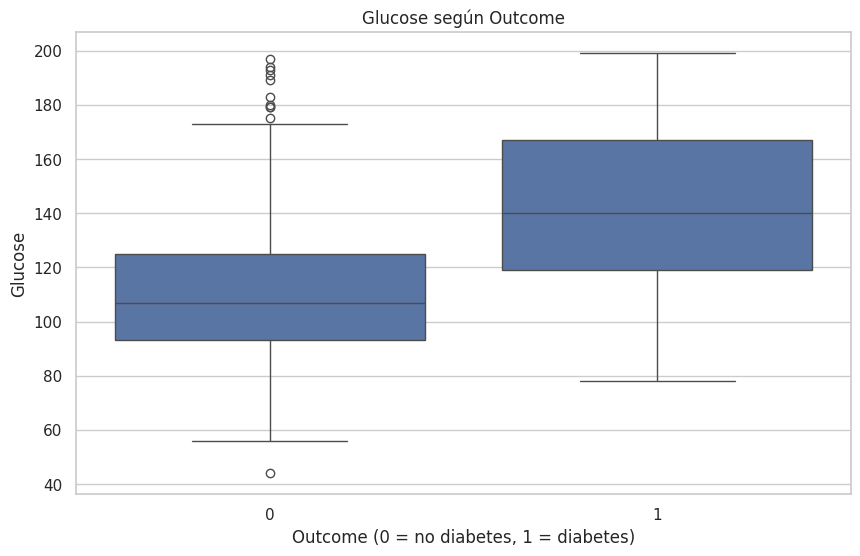

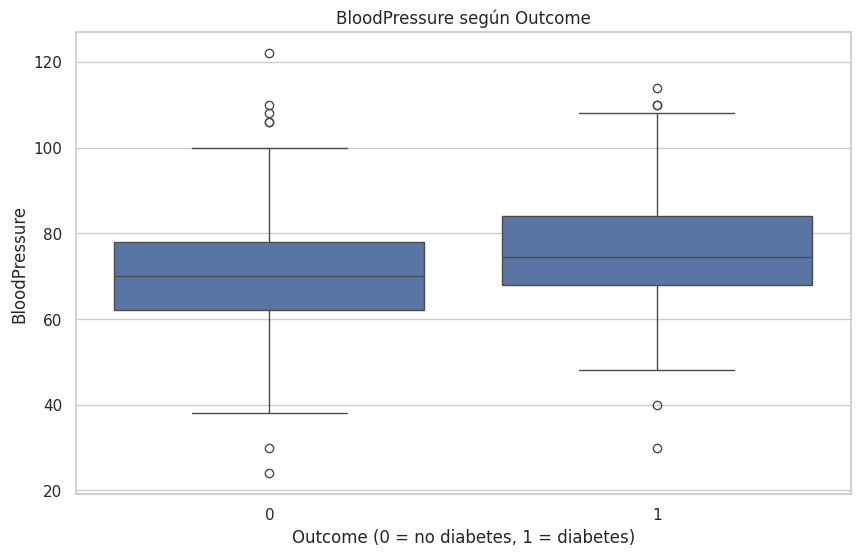

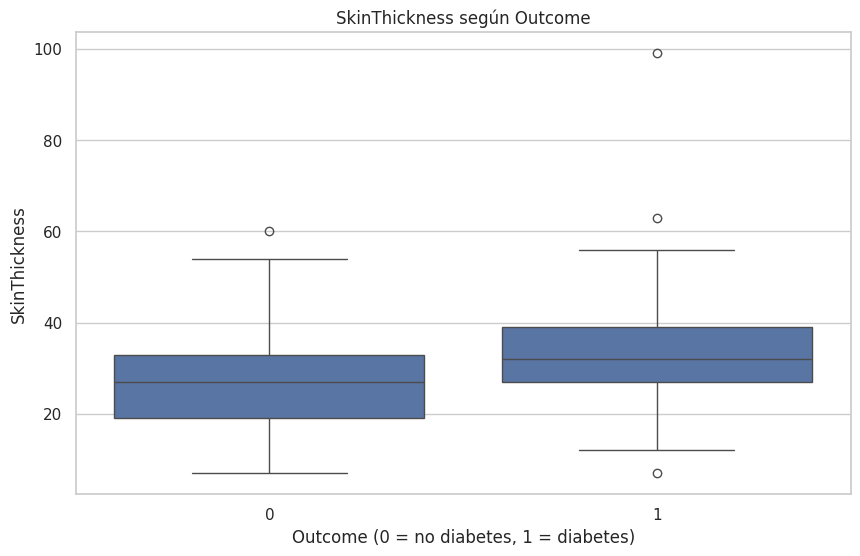

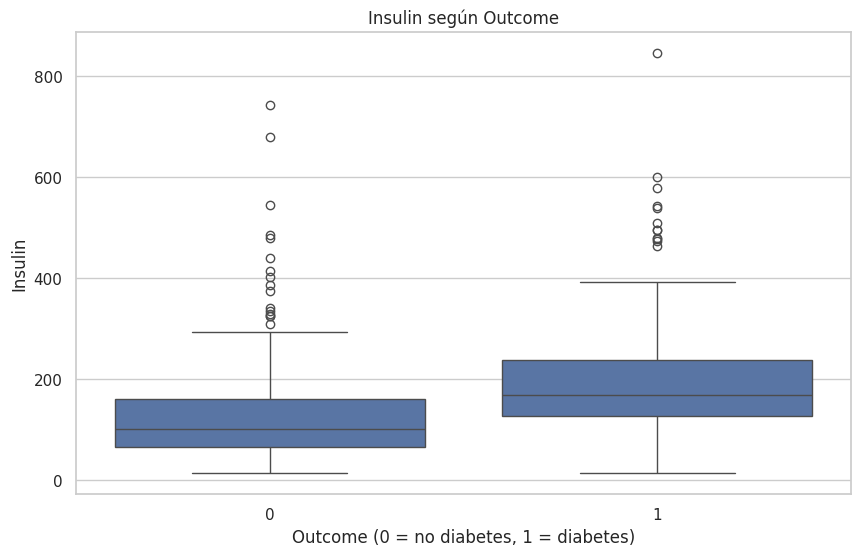

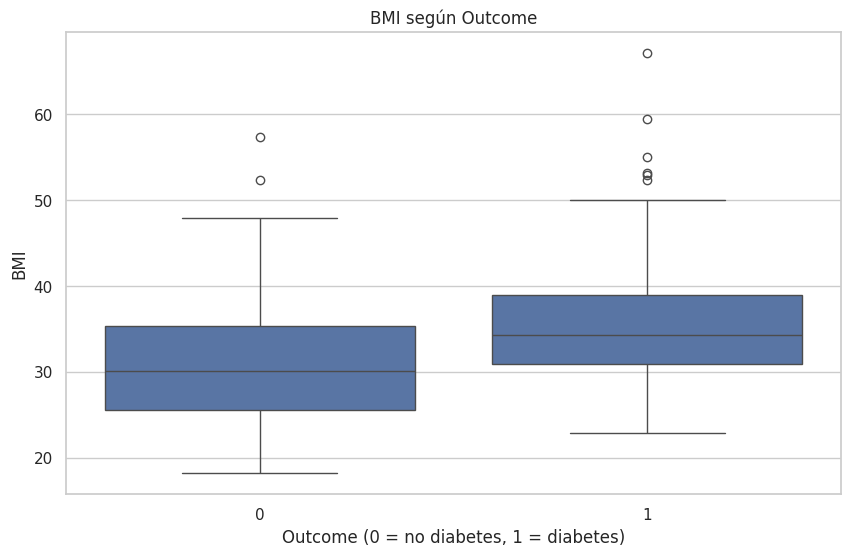

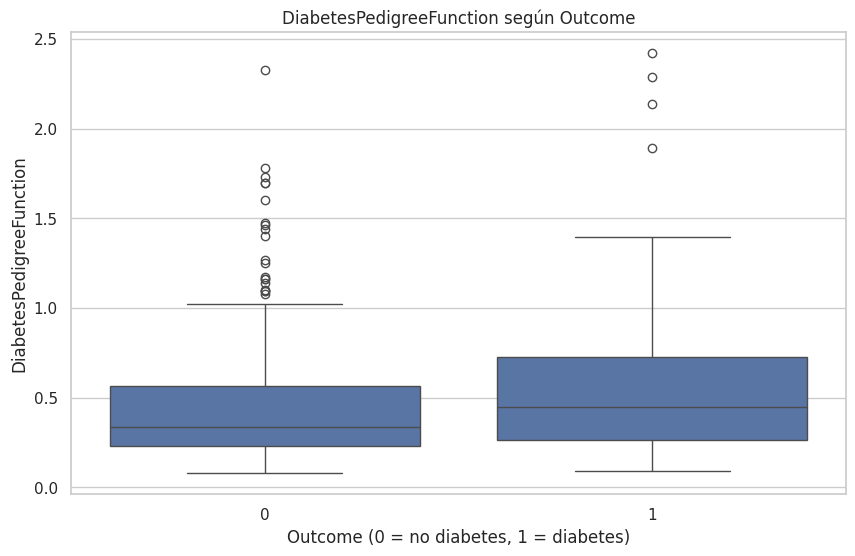

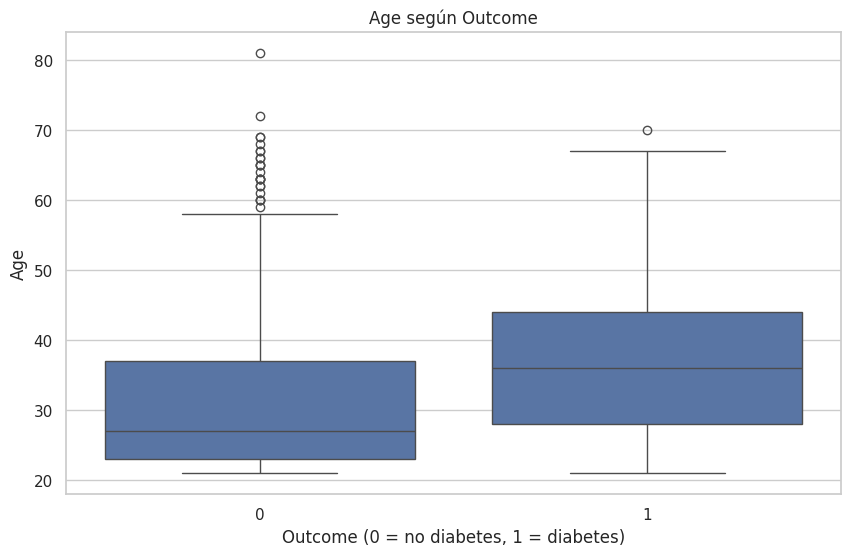

In [ ]:
# ==========================================
# BLOQUE 11. BOXPLOTS POR OUTCOME
# ==========================================

for col in variables:
    plt.figure()
    sns.boxplot(data=df_clean, x="Outcome", y=col)
    plt.title(f"{col} según Outcome")
    plt.xlabel("Outcome (0 = no diabetes, 1 = diabetes)")
    plt.ylabel(col)
    plt.show()

In [ ]:
# ==========================================
# BLOQUE 12. PRUEBAS ESTADÍSTICAS ENTRE GRUPOS
# ==========================================

resultados = []

for col in variables:
    # separar la variable por grupo, quitando NaN
    grupo_no = df_clean[df_clean["Outcome"] == 0][col].dropna()
    grupo_si = df_clean[df_clean["Outcome"] == 1][col].dropna()

    # prueba no paramétrica Mann-Whitney U
    stat, p = stats.mannwhitneyu(grupo_no, grupo_si, alternative="two-sided")

    # tamaño de efecto simple basado en diferencia de medianas
    med_no = grupo_no.median()
    med_si = grupo_si.median()
    dif_med = med_si - med_no

    resultados.append({
        "Variable": col,
        "n_no_diabetes": len(grupo_no),
        "n_diabetes": len(grupo_si),
        "Mediana_no_diabetes": med_no,
        "Mediana_diabetes": med_si,
        "Diferencia_medianas": dif_med,
        "p_value": p
    })

resultados_df = pd.DataFrame(resultados).sort_values("p_value")

print("Resultados de pruebas Mann-Whitney U:")
print(resultados_df)

Resultados de pruebas Mann-Whitney U:
                   Variable  n_no_diabetes  n_diabetes  Mediana_no_diabetes  \
1                   Glucose            497         266              107.000   
7                       Age            500         268               27.000   
5                       BMI            491         266               30.100   
4                   Insulin            264         130              102.500   
3             SkinThickness            361         180               27.000   
0               Pregnancies            500         268                2.000   
6  DiabetesPedigreeFunction            500         268                0.336   
2             BloodPressure            481         252               70.000   

   Mediana_diabetes  Diferencia_medianas       p_value  
1           140.000               33.000  1.305039e-40  
7            36.000                9.000  1.142200e-17  
5            34.300                4.200  1.818811e-17  
4           169.500   

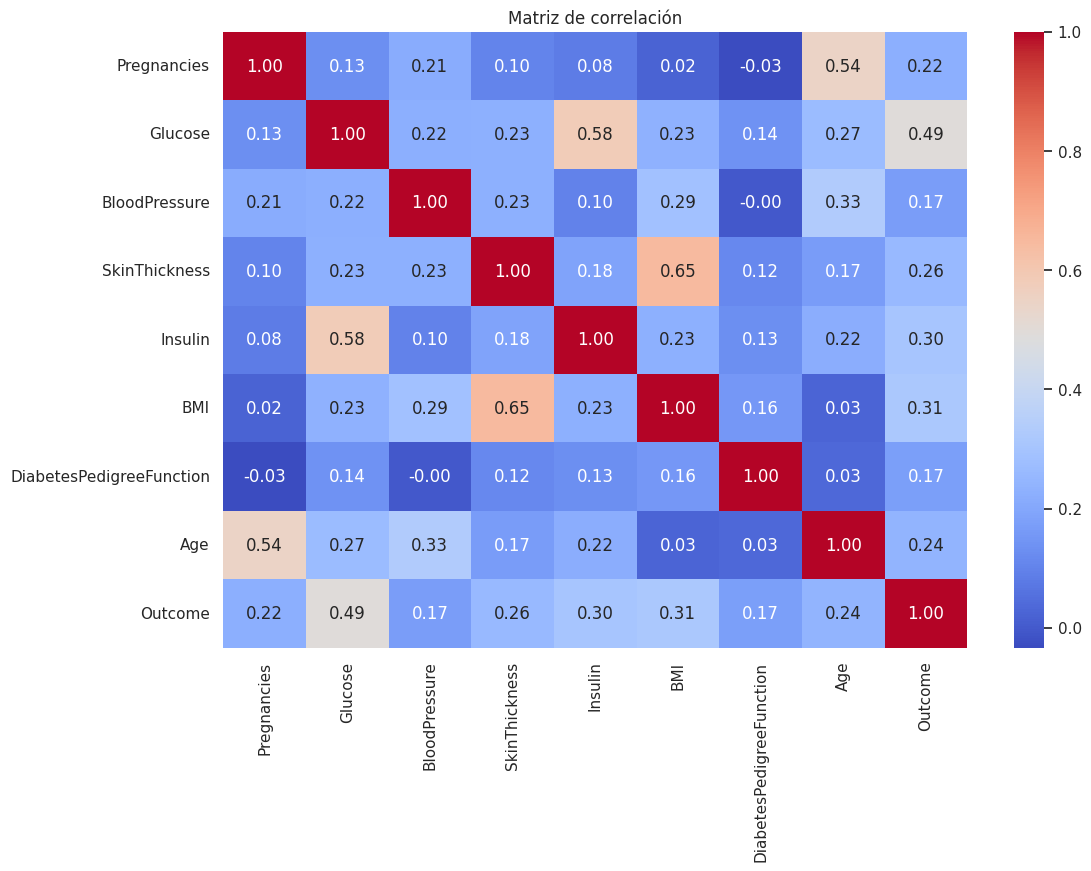

Correlación de cada variable con Outcome:
Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64


In [ ]:
# ==========================================
# BLOQUE 13. CORRELACIONES
# ==========================================

# calcular matriz de correlación de Pearson
corr_matrix = df_clean.corr(numeric_only=True)

# mostrar heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

# ordenar correlación con Outcome
corr_outcome = corr_matrix["Outcome"].drop("Outcome").sort_values(ascending=False)

print("Correlación de cada variable con Outcome:")
print(corr_outcome)

Probabilidad de diabetes según número de embarazos:
  grupo_embarazos    n  casos_diabetes  prob_diabetes
0               0  111              38       0.342342
1             1-2  238              48       0.201681
2             3-5  200              71       0.355000
3         6 o más  219             111       0.506849


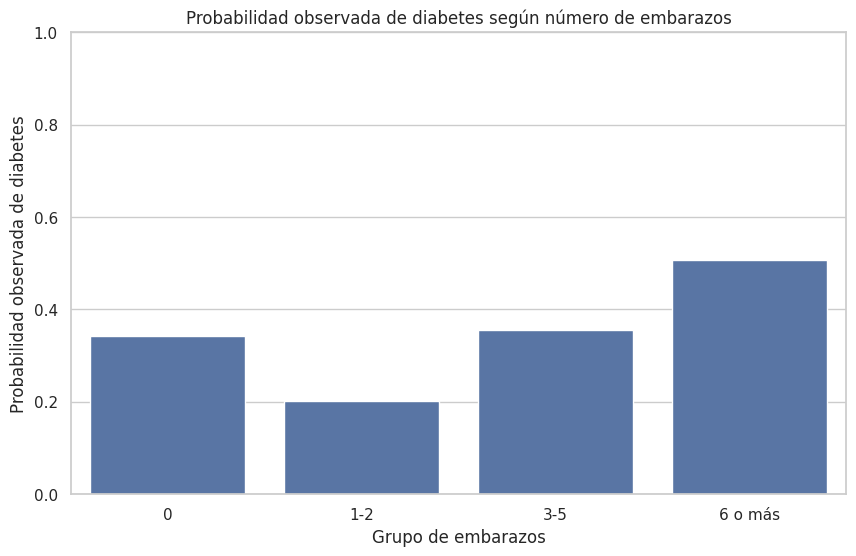

In [ ]:
#Probabilidad de diabetes por categorías de embarazo
# ==========================================
# BLOQUE 15. ANÁLISIS DE PREGNANCIES
# ==========================================

# crear copia con categorías clínicas simples
temp_preg = df_clean[["Pregnancies", "Outcome"]].copy()

# categorizar número de embarazos
temp_preg["grupo_embarazos"] = pd.cut(
    temp_preg["Pregnancies"],
    bins=[-1, 0, 2, 5, 20],
    labels=["0", "1-2", "3-5", "6 o más"]
)

# calcular prevalencia por grupo
prob_preg = temp_preg.groupby("grupo_embarazos", observed=False).agg(
    n=("Outcome", "count"),
    casos_diabetes=("Outcome", "sum"),
    prob_diabetes=("Outcome", "mean")
).reset_index()

print("Probabilidad de diabetes según número de embarazos:")
print(prob_preg)

# gráfica
plt.figure()
sns.barplot(data=prob_preg, x="grupo_embarazos", y="prob_diabetes")
plt.title("Probabilidad observada de diabetes según número de embarazos")
plt.xlabel("Grupo de embarazos")
plt.ylabel("Probabilidad observada de diabetes")
plt.ylim(0, 1)
plt.show()

In [ ]:
# ==========================================
# BLOQUE 16. PROBABILIDAD CONDICIONADA POR CUARTILES
# ==========================================

resultados_prob = []

for col in variables:
    temp = df_clean[[col, "Outcome"]].dropna().copy()

    # calcular cuartiles
    q1 = temp[col].quantile(0.25)
    q3 = temp[col].quantile(0.75)

    # grupo bajo: <= Q1
    grupo_bajo = temp[temp[col] <= q1]

    # grupo alto: >= Q3
    grupo_alto = temp[temp[col] >= q3]

    # probabilidad empírica de diabetes en cada grupo
    p_bajo = grupo_bajo["Outcome"].mean()
    p_alto = grupo_alto["Outcome"].mean()

    # razón de probabilidades simple
    razon = p_alto / p_bajo if p_bajo != 0 else np.nan

    resultados_prob.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "P(Diabetes | bajo)": p_bajo,
        "P(Diabetes | alto)": p_alto,
        "Razon_simple_alto_vs_bajo": razon
    })

resultados_prob_df = pd.DataFrame(resultados_prob).sort_values("Razon_simple_alto_vs_bajo", ascending=False)

print("Comparación de probabilidad de diabetes entre cuartil alto y bajo:")
print(resultados_prob_df)

Comparación de probabilidad de diabetes entre cuartil alto y bajo:
                   Variable        Q1         Q3  P(Diabetes | bajo)  \
1                   Glucose  99.00000  141.00000            0.072917   
4                   Insulin  76.25000  190.00000            0.080808   
5                       BMI  27.50000   36.60000            0.113990   
7                       Age  24.00000   41.00000            0.141553   
3             SkinThickness  22.00000   36.00000            0.153333   
2             BloodPressure  64.00000   80.00000            0.228856   
6  DiabetesPedigreeFunction   0.24375    0.62625            0.255208   
0               Pregnancies   1.00000    6.00000            0.272358   

   P(Diabetes | alto)  Razon_simple_alto_vs_bajo  
1            0.687500                   9.428571  
4            0.514851                   6.371287  
5            0.487047                   4.272727  
7            0.525773                   3.714333  
3            0.468966        

Tabla final de evidencia estadística y probabilística:
                   Variable  n_no_diabetes  n_diabetes  Mediana_no_diabetes  \
0                   Glucose            497         266              107.000   
1                       Age            500         268               27.000   
2                       BMI            491         266               30.100   
3                   Insulin            264         130              102.500   
4             SkinThickness            361         180               27.000   
5               Pregnancies            500         268                2.000   
6  DiabetesPedigreeFunction            500         268                0.336   
7             BloodPressure            481         252               70.000   

   Mediana_diabetes  Diferencia_medianas       p_value  Correlacion_Outcome  \
0           140.000               33.000  1.305039e-40             0.494650   
1            36.000                9.000  1.142200e-17             0.238356

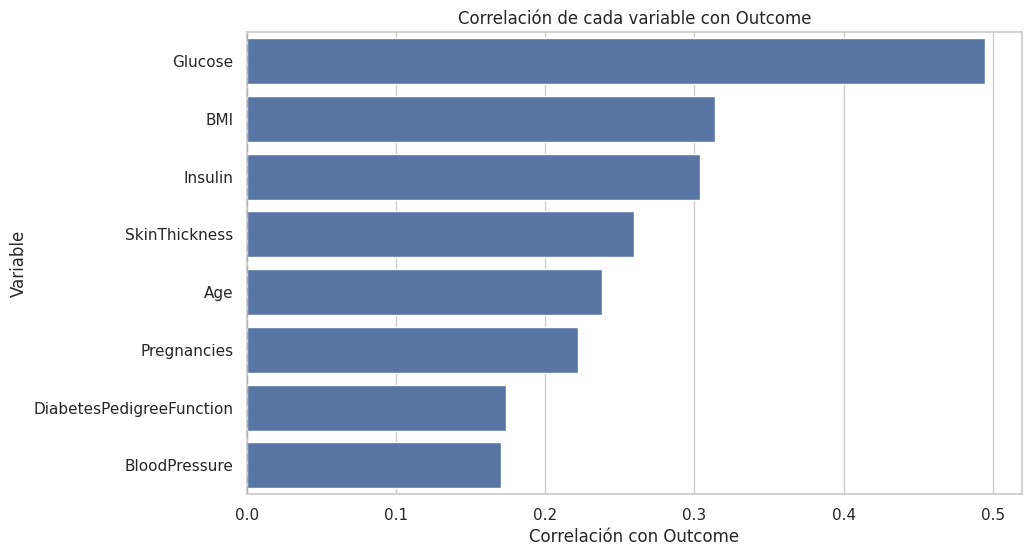

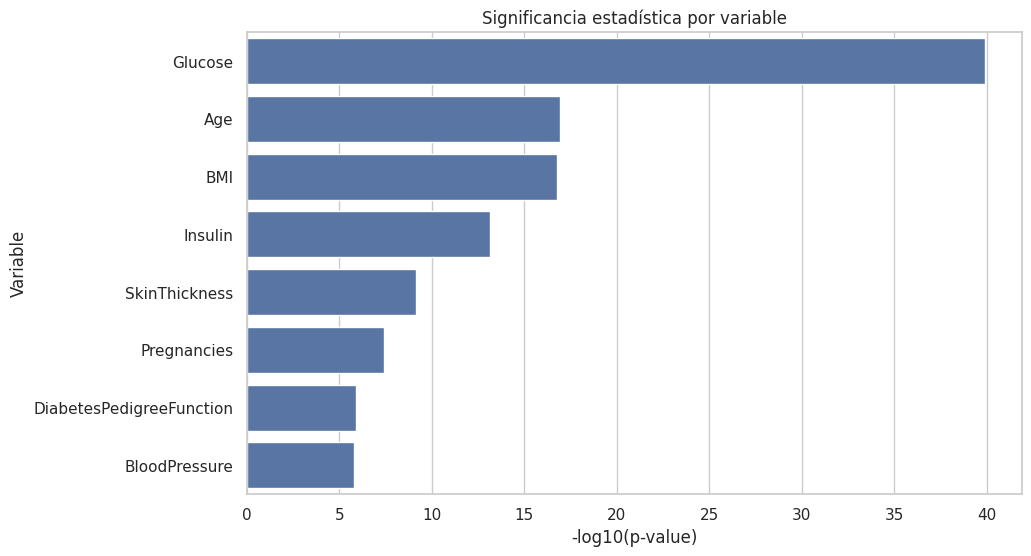

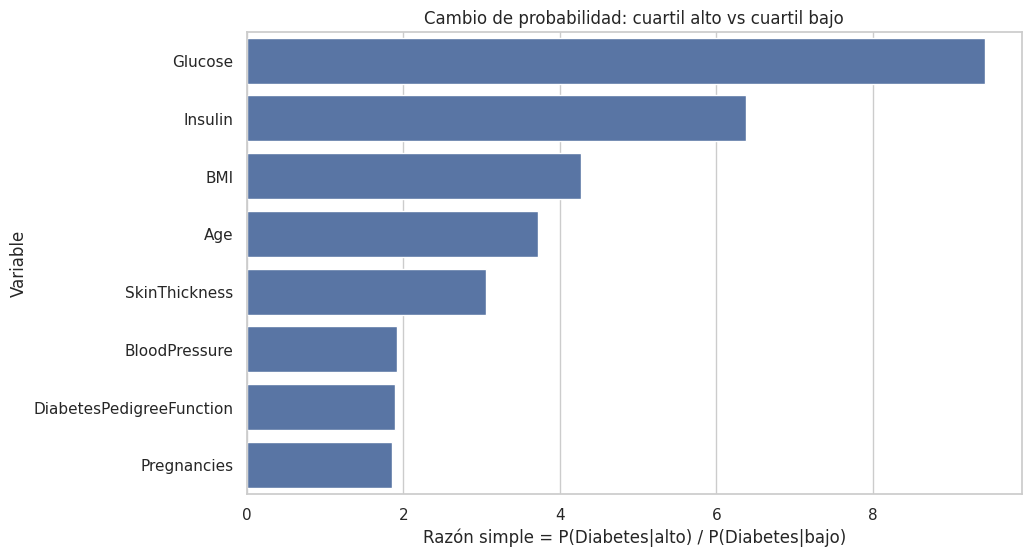

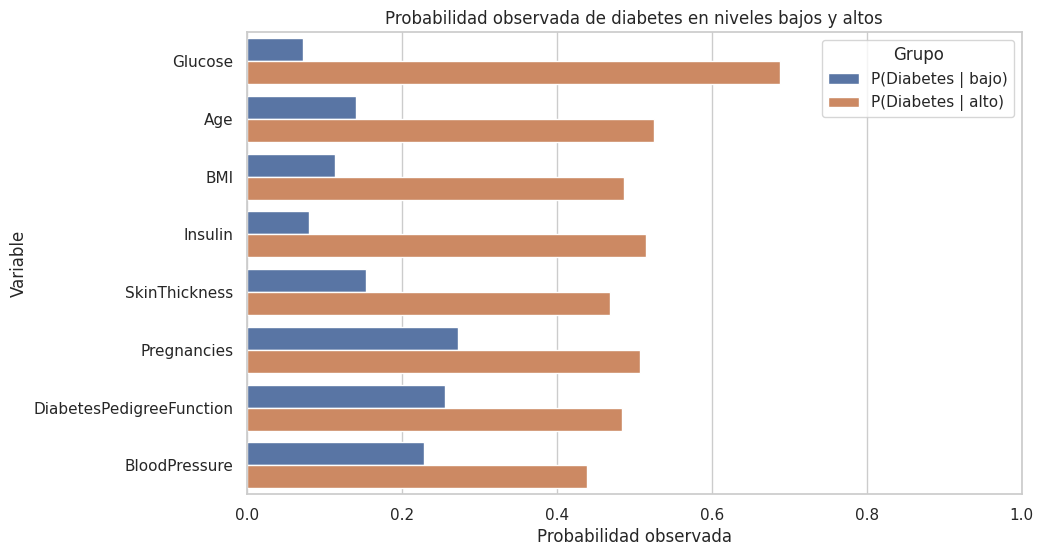

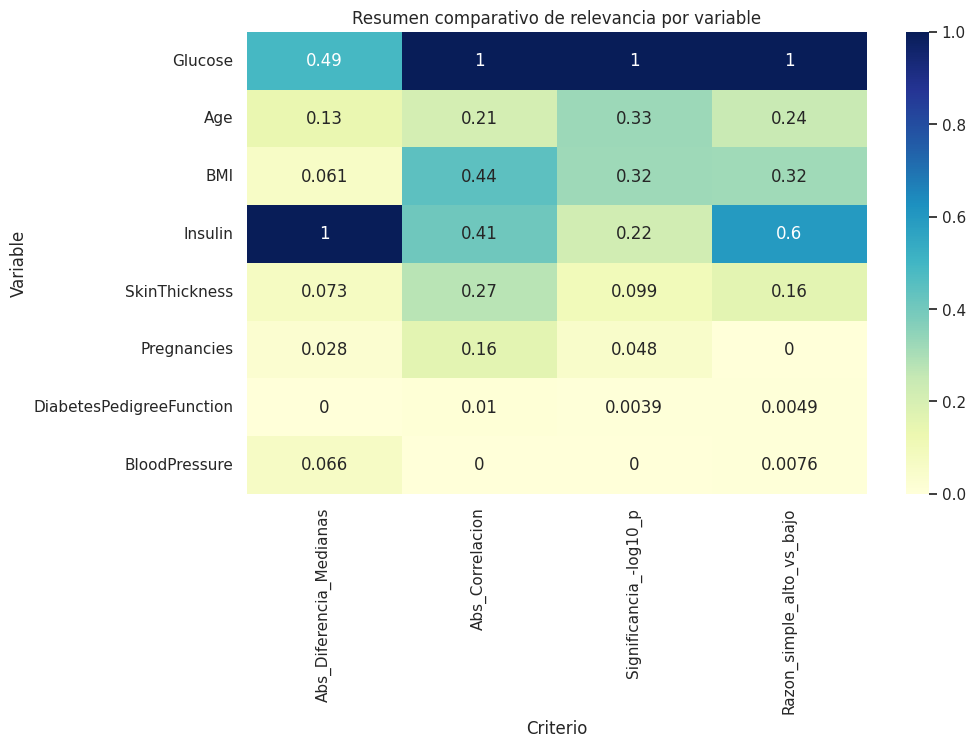

In [ ]:
# ==========================================
# BLOQUE 17. RESUMEN FINAL DE RELEVANCIA
# CON TABLA Y GRÁFICAS
# ==========================================

# ------------------------------------------
# 1. Preparar tabla de correlaciones
# ------------------------------------------

# corr_outcome viene del BLOQUE 13
# lo convertimos en dataframe para poder unirlo
corr_outcome_df = corr_outcome.reset_index()
corr_outcome_df.columns = ["Variable", "Correlacion_Outcome"]

# ------------------------------------------
# 2. Unir toda la evidencia en una sola tabla
# ------------------------------------------

# resultados_df viene del BLOQUE 12
# resultados_prob_df viene del BLOQUE 16

tabla_final = resultados_df.merge(
    corr_outcome_df,
    on="Variable",
    how="left"
).merge(
    resultados_prob_df[
        ["Variable", "P(Diabetes | bajo)", "P(Diabetes | alto)", "Razon_simple_alto_vs_bajo"]
    ],
    on="Variable",
    how="left"
)

# ------------------------------------------
# 3. Crear métricas auxiliares para graficar
# ------------------------------------------

# transformar el p-value para que sea más fácil de visualizar
# mientras más grande sea -log10(p), más significativa es la variable
tabla_final["Significancia_-log10_p"] = -np.log10(tabla_final["p_value"])

# valor absoluto de la correlación para medir fuerza sin importar signo
tabla_final["Abs_Correlacion"] = tabla_final["Correlacion_Outcome"].abs()

# magnitud absoluta de la diferencia de medianas
tabla_final["Abs_Diferencia_Medianas"] = tabla_final["Diferencia_medianas"].abs()

# ------------------------------------------
# 4. Ordenar tabla final
# ------------------------------------------

# ordenamos por significancia estadística y luego por razón de probabilidad
tabla_final = tabla_final.sort_values(
    by=["p_value", "Razon_simple_alto_vs_bajo"],
    ascending=[True, False]
).reset_index(drop=True)

# mostrar tabla final
print("Tabla final de evidencia estadística y probabilística:")
print(tabla_final)

# ------------------------------------------
# 5. GRÁFICA 1:
# Correlación con Outcome
# ------------------------------------------

plt.figure(figsize=(10, 6))
sns.barplot(
    data=tabla_final.sort_values("Correlacion_Outcome", ascending=False),
    x="Correlacion_Outcome",
    y="Variable"
)
plt.title("Correlación de cada variable con Outcome")
plt.xlabel("Correlación con Outcome")
plt.ylabel("Variable")
plt.axvline(0, color="black", linestyle="--")
plt.show()

# ------------------------------------------
# 6. GRÁFICA 2:
# Significancia estadística (-log10 p-value)
# ------------------------------------------

plt.figure(figsize=(10, 6))
sns.barplot(
    data=tabla_final.sort_values("Significancia_-log10_p", ascending=False),
    x="Significancia_-log10_p",
    y="Variable"
)
plt.title("Significancia estadística por variable")
plt.xlabel("-log10(p-value)")
plt.ylabel("Variable")
plt.show()

# ------------------------------------------
# 7. GRÁFICA 3:
# Razón de probabilidad alto vs bajo
# ------------------------------------------

plt.figure(figsize=(10, 6))
sns.barplot(
    data=tabla_final.sort_values("Razon_simple_alto_vs_bajo", ascending=False),
    x="Razon_simple_alto_vs_bajo",
    y="Variable"
)
plt.title("Cambio de probabilidad: cuartil alto vs cuartil bajo")
plt.xlabel("Razón simple = P(Diabetes|alto) / P(Diabetes|bajo)")
plt.ylabel("Variable")
plt.show()

# ------------------------------------------
# 8. GRÁFICA 4:
# Probabilidad observada en nivel bajo vs alto
# ------------------------------------------

# reorganizar datos a formato largo para comparar bajo vs alto
plot_prob = tabla_final[["Variable", "P(Diabetes | bajo)", "P(Diabetes | alto)"]].copy()

plot_prob = plot_prob.melt(
    id_vars="Variable",
    value_vars=["P(Diabetes | bajo)", "P(Diabetes | alto)"],
    var_name="Grupo",
    value_name="Probabilidad"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_prob,
    x="Probabilidad",
    y="Variable",
    hue="Grupo"
)
plt.title("Probabilidad observada de diabetes en niveles bajos y altos")
plt.xlabel("Probabilidad observada")
plt.ylabel("Variable")
plt.xlim(0, 1)
plt.show()

# ------------------------------------------
# 9. GRÁFICA 5:
# Heatmap comparativo normalizado
# ------------------------------------------

# seleccionar columnas clave
heatmap_df = tabla_final[
    ["Variable", "Abs_Diferencia_Medianas", "Abs_Correlacion",
     "Significancia_-log10_p", "Razon_simple_alto_vs_bajo"]
].copy()

# poner Variable como índice
heatmap_df = heatmap_df.set_index("Variable")

# normalizar cada columna entre 0 y 1
heatmap_norm = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min())

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_norm, annot=True, cmap="YlGnBu")
plt.title("Resumen comparativo de relevancia por variable")
plt.xlabel("Criterio")
plt.ylabel("Variable")
plt.show()

In [ ]:
# ==========================================
# BLOQUE 18. PERFIL OBSERVADO DE MAYOR RIESGO
# ==========================================

# calcular medianas por grupo Outcome
perfil = df_clean.groupby("Outcome")[variables].median().T
perfil.columns = ["Mediana_no_diabetes", "Mediana_diabetes"]

print("Perfil típico según medianas por grupo:")
print(perfil)

Perfil típico según medianas por grupo:
                          Mediana_no_diabetes  Mediana_diabetes
Pregnancies                             2.000             4.000
Glucose                               107.000           140.000
BloodPressure                          70.000            74.500
SkinThickness                          27.000            32.000
Insulin                               102.500           169.500
BMI                                    30.100            34.300
DiabetesPedigreeFunction                0.336             0.449
Age                                    27.000            36.000


Perfil típico según medianas por grupo:
                          Mediana_no_diabetes  Mediana_diabetes
Pregnancies                             2.000             4.000
Glucose                               107.000           140.000
BloodPressure                          70.000            74.500
SkinThickness                          27.000            32.000
Insulin                               102.500           169.500
BMI                                    30.100            34.300
DiabetesPedigreeFunction                0.336             0.449
Age                                    27.000            36.000

Perfil con diferencia entre grupos:
                          Mediana_no_diabetes  Mediana_diabetes  Diferencia
Insulin                               102.500           169.500      67.000
Glucose                               107.000           140.000      33.000
Age                                    27.000            36.000       9.000
SkinThickness                          27.0

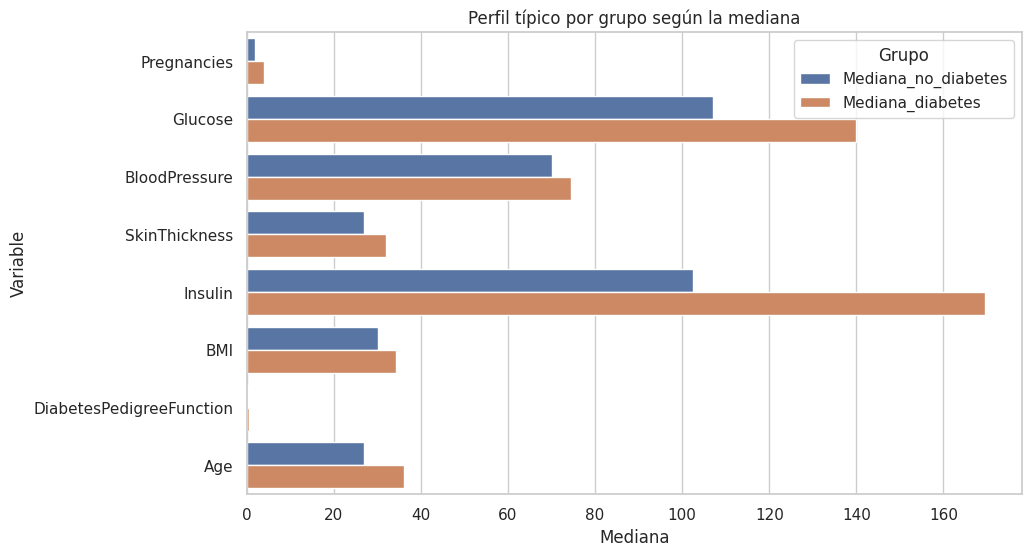

In [ ]:
# ==========================================
# BLOQUE 18. PERFIL OBSERVADO DE MAYOR RIESGO
# CON TABLA Y GRÁFICAS
# ==========================================

# ------------------------------------------
# 1. Calcular medianas por grupo
# ------------------------------------------

# agrupar por Outcome y calcular la mediana de cada variable
perfil = df_clean.groupby("Outcome")[variables].median().T

# renombrar columnas para que sea más claro
perfil.columns = ["Mediana_no_diabetes", "Mediana_diabetes"]

# mostrar tabla
print("Perfil típico según medianas por grupo:")
print(perfil)

# ------------------------------------------
# 2. Crear diferencia entre grupos
# ------------------------------------------

# calcular cuánto cambia la mediana en el grupo con diabetes
# respecto al grupo sin diabetes
perfil["Diferencia"] = perfil["Mediana_diabetes"] - perfil["Mediana_no_diabetes"]

# ordenar por diferencia descendente para ver qué variables cambian más
perfil_ordenado = perfil.sort_values("Diferencia", ascending=False)

print("\nPerfil con diferencia entre grupos:")
print(perfil_ordenado)

# ------------------------------------------
# 3. GRÁFICA 1: barras comparativas de medianas
# ------------------------------------------

# pasar a formato largo para graficar mejor con seaborn
perfil_plot = perfil.reset_index().rename(columns={"index": "Variable"})

perfil_plot = perfil_plot.melt(
    id_vars="Variable",
    value_vars=["Mediana_no_diabetes", "Mediana_diabetes"],
    var_name="Grupo",
    value_name="Mediana"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=perfil_plot,
    x="Mediana",
    y="Variable",
    hue="Grupo"
)
plt.title("Perfil típico por grupo según la mediana")
plt.xlabel("Mediana")
plt.ylabel("Variable")
plt.show()


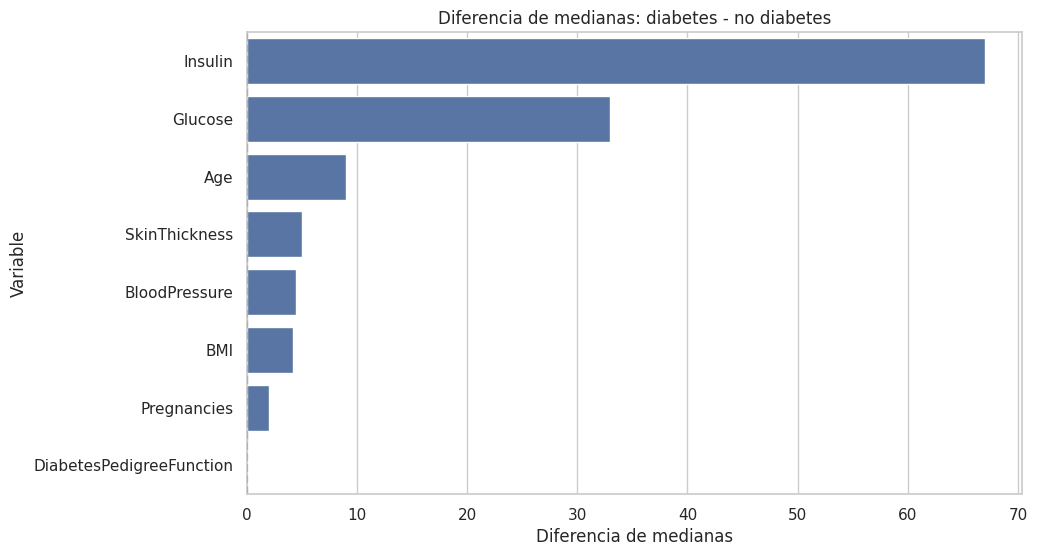

In [ ]:
# ------------------------------------------
# 4. GRÁFICA 2: diferencia de medianas
# ------------------------------------------

plt.figure(figsize=(10, 6))
sns.barplot(
    data=perfil_ordenado.reset_index(),
    x="Diferencia",
    y="index"
)
plt.title("Diferencia de medianas: diabetes - no diabetes")
plt.xlabel("Diferencia de medianas")
plt.ylabel("Variable")
plt.axvline(0, color="black", linestyle="--")
plt.show()

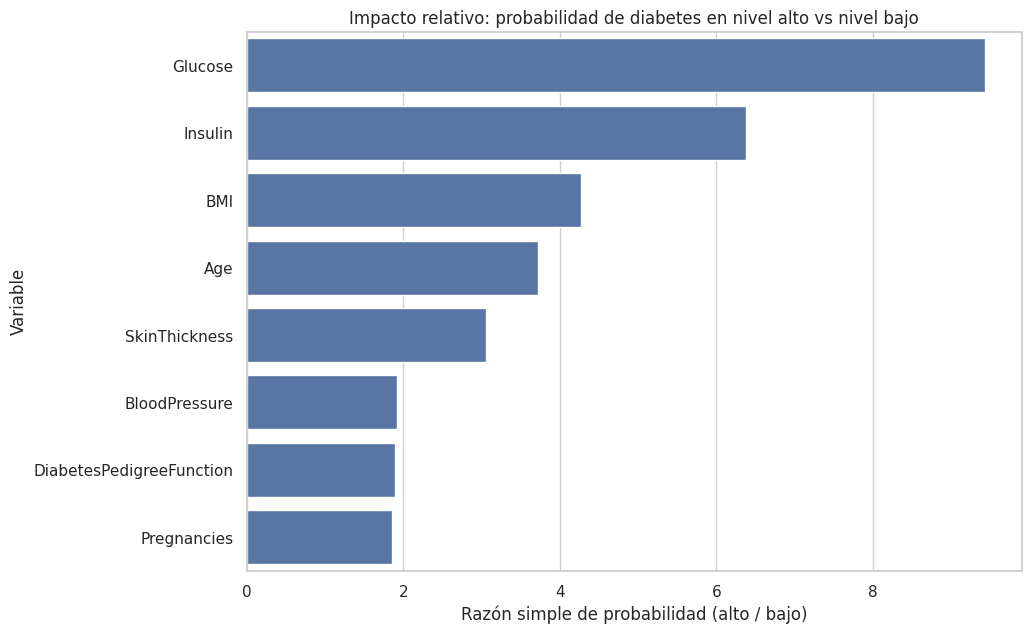

In [ ]:
# ==========================================
# BLOQUE 19. GRÁFICA RESUMEN DE IMPACTO
# ==========================================

# ordenar de mayor a menor razón
plot_df = resultados_prob_df.sort_values("Razon_simple_alto_vs_bajo", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=plot_df, x="Razon_simple_alto_vs_bajo", y="Variable")
plt.title("Impacto relativo: probabilidad de diabetes en nivel alto vs nivel bajo")
plt.xlabel("Razón simple de probabilidad (alto / bajo)")
plt.ylabel("Variable")
plt.show()